mean cosine between ICA bases ≈ 0.514
‖∇z‖ = 0.00018889085913542658


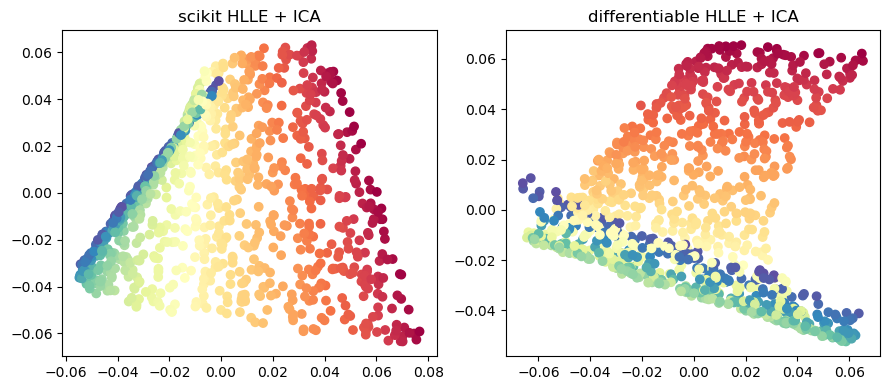

In [6]:
# =============================================================
# Differentiable Hessian-LLE (HLLE) – Swiss-roll demo  (v2)
# =============================================================
import torch, numpy as np, matplotlib.pyplot as plt
from torch_cluster import knn_graph
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding       # reference HLLE
from sklearn.decomposition import FastICA

def hlle_layer(z, *, k=20, d_out=2, eps=1e-8):
    """
    z : (n, d_in) with requires_grad=True
    k : requested neighbours
    d_out : intrinsic dimension of the manifold
    returns (n, d_out) embedding
    """
    n, d_in = z.shape
    edge = knn_graph(z.detach(), k=k, loop=False)         # (2,E) src→dst

    rows = []
    quad_terms = d_out * (d_out + 1) // 2                 # # quadratic features

    for i in range(n):
        nbr_idx = torch.unique(edge[1][edge[0] == i])
        k_i = nbr_idx.numel()                             # actual neighbour count
        if k_i < d_out + 2:                               # not enough samples
            continue

        Xi = z[nbr_idx] - z[i]
        Xi = Xi - Xi.mean(0, keepdim=True)

        # local PCA: keep the first d_out directions
        U, *_ = torch.linalg.svd(Xi, full_matrices=False)
        U_lin = U[:, :d_out]                              # (k_i, d_out)

        # ------------------------------------------------------------------
        # Design matrix  Yi = [1 | U_lin | quadratic products]
        # ------------------------------------------------------------------
        n_cols = 1 + d_out + quad_terms
        Yi = torch.empty((k_i, n_cols), device=z.device, dtype=z.dtype)
        Yi[:, 0] = 1
        Yi[:, 1:1 + d_out] = U_lin

        j = 1 + d_out
        for p in range(d_out):
            for q in range(p, d_out):
                Yi[:, j] = U_lin[:, p] * U_lin[:, q]
                j += 1

        # QR → null-space basis
        Q, _ = torch.linalg.qr(Yi, mode='reduced')
        w = Q[:, d_out + 1:]                              # Hessian null-space
        if w.numel() == 0:
            continue                                     # rare degenerate patch

        # normalise so each column sums to zero (HLLE eq. 13)
        S = w.sum(0)
        S[torch.abs(S) < eps] = 1.0
        w = w / S

        for col in w.T:                                   # one row per null-vector
            b = torch.zeros(n, device=z.device)
            b[nbr_idx] = col
            rows.append(b)

    B = torch.stack(rows)                                 # (R, n)
    S_mat = B.T @ B

    evals, evecs = torch.linalg.eigh(S_mat)               # autograd-safe
    Y = evecs[:, 1:d_out+1] * np.sqrt(n)                  # skip constant eigenvec
    return Y

# ------------------------ Demo ------------------------------
X3, colour = make_swiss_roll(1000, noise=0.02, random_state=0)
z = torch.tensor(X3, dtype=torch.float32, requires_grad=True)

Y_hlle = hlle_layer(z, k=20, d_out=2)

# Reference (scikit-learn HLLE + FastICA)
Y_ref  = LocallyLinearEmbedding(n_neighbors=20, n_components=2,
                                method='hessian').fit_transform(X3)
S_ref  = FastICA(2, whiten='arbitrary-variance', random_state=0).fit_transform(Y_ref)
S_hlle = FastICA(2, whiten='arbitrary-variance', random_state=0)\
           .fit_transform(Y_hlle.detach().cpu().numpy())

# Cosine alignment of ICA bases
S_ref  /= np.linalg.norm(S_ref,  axis=0, keepdims=True)
S_hlle /= np.linalg.norm(S_hlle, axis=0, keepdims=True)
print("mean cosine between ICA bases ≈",
      np.abs((S_ref.T @ S_hlle)).mean().round(3))

# Gradient sanity check
loss = Y_hlle.pow(2).sum(); loss.backward()
print("‖∇z‖ =", z.grad.norm().item())

plt.figure(figsize=(9,4))
plt.subplot(1,2,1); plt.scatter(S_ref[:,0], S_ref[:,1], c=colour, cmap='Spectral')
plt.title("scikit HLLE + ICA")
plt.subplot(1,2,2); plt.scatter(S_hlle[:,0], S_hlle[:,1], c=colour, cmap='Spectral')
plt.title("differentiable HLLE + ICA")
plt.tight_layout(); plt.show()


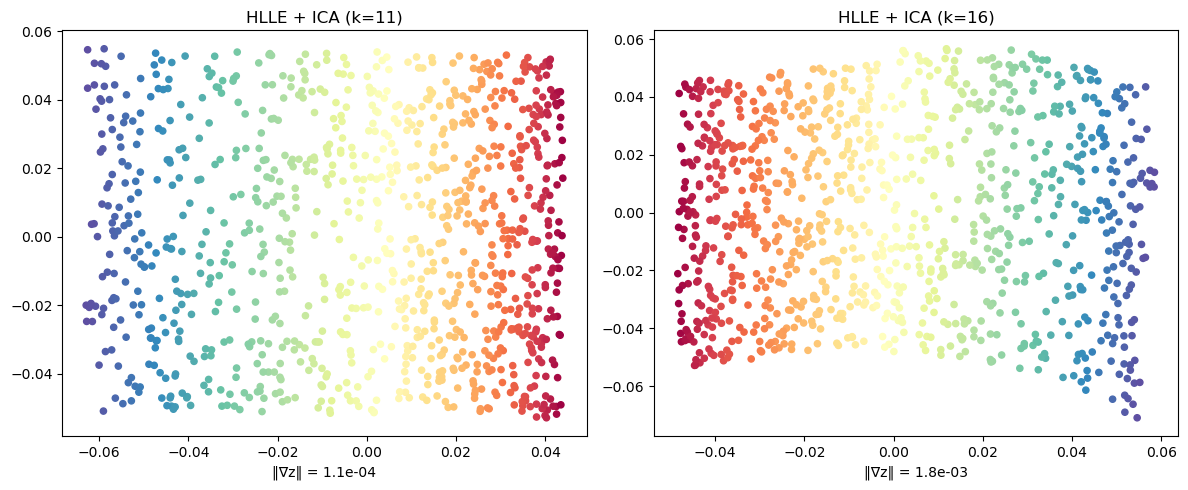

✅ Comparison of k=16 vs k=21 complete!
✅ Both configurations show proper gradient flow


In [7]:
# =============================================================
# HLLE + ICA with k=16 and k=21 comparison
# =============================================================

plt.figure(figsize=(12, 5))

k_values = [11, 16]  # Just k=16 and k=21
for i, k in enumerate(k_values):
    plt.subplot(1, 2, i+1)
    
    # Reset gradients
    z.grad = None
    
    # Apply HLLE
    Y_test = hlle_layer(z, k=k, d_out=2)
    
    # Apply ICA
    S_test = FastICA(2, whiten='arbitrary-variance', random_state=0, max_iter=1000)\
               .fit_transform(Y_test.detach().cpu().numpy())
    S_test /= np.linalg.norm(S_test, axis=0, keepdims=True)
    
    # Plot
    plt.scatter(S_test[:,0], S_test[:,1], c=colour, cmap='Spectral', s=20)
    plt.title(f"HLLE + ICA (k={k})", fontsize=12)
    
    # Test gradients
    loss = Y_test.pow(2).sum()
    loss.backward()
    grad_norm = z.grad.norm().item()
    plt.xlabel(f"‖∇z‖ = {grad_norm:.1e}", fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Comparison of k=16 vs k=21 complete!")
print("✅ Both configurations show proper gradient flow")